# Evaluate Model

Evaluate RT-DETR models on the v3 dataset.

**Model sources:**

- **W&B artifacts**: Load specific checkpoints (e.g. best mAP from a training round)
- **HF Hub**: Load published models from repo branches

**Metrics (all threshold-free):**

1. **mAP@50** — COCO IoU-based detection quality
2. **corner_R4** — top-4 corner recall (matches inference behaviour)
3. **stone_cdAP@2%** — macro center-distance AP for stones
4. Visual prediction browsing

## Configuration

In [1]:
%load_ext autoreload
%autoreload 2

import torch
from dotenv import load_dotenv

from datasets import load_dataset

from moku.dataset import CATEGORIES, ID_TO_CATEGORY
from moku.evaluation import (
    evaluate_cd_ap,
    evaluate_map,
)
from moku.runs import list_wandb_model_artifacts, load_model_from_wandb
from moku.model import collate_fn, make_eval_transform
from moku.viz import plot_model_comparison

load_dotenv()

HF_DATASET = "kaya-go/moku-v3"

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


## Load Datasets


In [2]:
ds = load_dataset(HF_DATASET)
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 1382
    })
    validation: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 53
    })
    test: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 50
    })
})


## Load Models from W&B

List available model artifacts and select which ones to evaluate.

In [3]:
# List available model artifacts from W&B
artifacts_df = list_wandb_model_artifacts()

cols = [
    c
    for c in ["name", "version", "aliases", "run", "eval_map", "eval_map_50", "epoch", "size_mb"]
    if c in artifacts_df.columns
]
display(artifacts_df[cols].sort_values("eval_map", ascending=False).reset_index(drop=True))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


,name,version,aliases,run,eval_map,eval_map_50,epoch,size_mb
0,model-r10_os3_lr2e-4_cosmin100:v12,v12,[latest],r10_os3_lr2e-4_cosmin100,0.616905,0.932758,27.0,80.5
1,model-r5_lr4e-4_linear500:v51,v51,[latest],r5_lr4e-4_linear500,0.607520,0.923377,413.0,80.5
2,model-r6_lr3e-4_cosmin1000:v27,v27,[latest],r6_lr3e-4_cosmin1000,0.595749,0.914674,730.0,80.5
3,model-r10_os3_lr3e-4_cosmin100:v9,v9,[latest],r10_os3_lr3e-4_cosmin100,0.586417,0.888975,39.0,80.5
4,model-r5_lr3e-4_cos500:v56,v56,[latest],r5_lr3e-4_cos500,0.584135,0.891032,318.0,80.5
5,model-r6_lr3e-4_linear1000:v47,v47,[latest],r6_lr3e-4_linear1000,0.580296,0.888961,916.0,80.5
6,model-r10_os5_lr2e-4_cosmin80:v6,v6,[latest],r10_os5_lr2e-4_cosmin80,0.576540,0.866355,34.0,80.5
7,model-r9_os5_lr5e-4_cosmin500:v13,v13,[latest],r9_os5_lr5e-4_cosmin500,0.572067,0.900033,26.0,80.5
8,model-r9_os3_lr3e-4_cosmin500:v26,v26,[latest],r9_os3_lr3e-4_cosmin500,0.567620,0.858724,36.0,80.5
9,model-r10_os5_lr3e-4_cosmin80:v4,v4,[latest],r10_os5_lr3e-4_cosmin80,0.565714,0.849315,28.0,80.5


Select artifacts to evaluate. Set the `ARTIFACTS` dict below (label → artifact name).

In [4]:
artifacts_df["name"].tolist()

['model-r10_os5_lr3e-4_cosmin80:v4',
 'model-r10_os5_lr1e-4_cosmin80:v12',
 'model-r10_os3_lr3e-4_cosmin100:v9',
 'model-r10_os5_lr2e-4_cosmin80:v6',
 'model-r10_os3_lr2e-4_cosmin100:v12',
 'model-r9_lr5e-4_linear500:v13',
 'model-r9_os5_lr5e-4_cosmin500:v13',
 'model-r9_os3_lr5e-4_cosmin500:v16',
 'model-r9_lr1e-4_linear500:v22',
 'model-r9_lr3e-4_linear500:v12',
 'model-r9_lr1e-4_cosmin500:v17',
 'model-r9_lr3e-4_cosmin500:v14',
 'model-r9_os3_lr3e-4_cosmin500:v26',
 'model-r9_os5_lr3e-4_cosmin500:v19',
 'model-r8_lr3e-4_cosmin500:v20',
 'model-r8_lr2e-4_cosmin500:v19',
 'model-r8_lr1e-4_linear500:v23',
 'model-r7_lr3e-4_cosmin500:v17',
 'model-r7_lr3e-4_linear500:v12',
 'model-r7_lr5e-4_linear500:v9',
 'model-r7_lr1e-4_linear500:v13',
 'model-r6_lr3e-4_cosmin1000:v27',
 'model-r6_lr4e-4_cosmin1000:v37',
 'model-r6_lr3e-4_linear1000:v47',
 'model-r6_lr4e-4_linear1000:v40',
 'model-r5_lr4e-4_linear500:v51',
 'model-r5_lr3e-4_cos500:v56']

In [5]:
from tqdm.auto import tqdm

# Set which artifacts to evaluate (base names, :latest is appended automatically)
ARTIFACTS = [
    "model-r5_lr4e-4_linear500",
    "model-r6_lr4e-4_cosmin1000",
    "model-r7_lr5e-4_linear500",
    "model-r8_lr3e-4_cosmin500",
    "model-r9_os5_lr5e-4_cosmin500",
    "model-r10_os5_lr3e-4_cosmin80",
    "model-r10_os5_lr1e-4_cosmin80",
    "model-r10_os3_lr3e-4_cosmin100",
    "model-r10_os5_lr2e-4_cosmin80",
    "model-r10_os3_lr2e-4_cosmin100",
]

# Load models
models = {}
for name in tqdm(ARTIFACTS, desc="Loading models", leave=False):
    ip, model = load_model_from_wandb(f"{name}:latest")
    models[name] = {"ip": ip, "model": model}

print(f"Loaded {len(models)} models: {list(models.keys())}")

Loading models:   0%|          | 0/10 [00:00<?, ?it/s]

wandb: Downloading large artifact 'model-r5_lr4e-4_linear500:latest', 76.78MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:00.3 (281.6MB/s)


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

wandb: Downloading large artifact 'model-r6_lr4e-4_cosmin1000:latest', 76.78MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:00.3 (289.6MB/s)


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

...

wandb: Downloading large artifact 'model-r10_os5_lr2e-4_cosmin80:latest', 76.78MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:07.7 (10.0MB/s)


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

wandb: Downloading large artifact 'model-r10_os3_lr2e-4_cosmin100:latest', 76.78MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:07.8 (9.8MB/s)


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Loaded 10 models: ['model-r5_lr4e-4_linear500', 'model-r6_lr4e-4_cosmin1000', 'model-r7_lr5e-4_linear500', 'model-r8_lr3e-4_cosmin500', 'model-r9_os5_lr5e-4_cosmin500', 'model-r10_os5_lr3e-4_cosmin80', 'model-r10_os5_lr1e-4_cosmin80', 'model-r10_os3_lr3e-4_cosmin100', 'model-r10_os5_lr2e-4_cosmin80', 'model-r10_os3_lr2e-4_cosmin100']


## Evaluate on Validation

All key metrics are **threshold-free** — no confidence threshold to choose.

In [ ]:
import numpy as np
import pandas as pd

# ── Run evaluations on validation set ──
val_metrics_map = {}
val_cd_ap = {}

for label, entry in tqdm(models.items(), desc="Evaluating models"):
    ds.set_transform(make_eval_transform(entry["ip"]))
    val_metrics_map[label] = evaluate_map(
        model=entry["model"],
        dataset=ds["validation"],
        image_processor=entry["ip"],
        batch_size=16,
    )
    val_cd_ap[label] = evaluate_cd_ap(
        model=entry["model"],
        dataset=ds["validation"],
        image_processor=entry["ip"],
        batch_size=16,
    )

# ── Build summary DataFrame ──
val_summary_rows = []
for label in models:
    row = {"model": label}
    row["mAP"] = val_metrics_map[label].get("map", float("nan"))
    row["mAP@50"] = val_metrics_map[label].get("map_50", float("nan"))
    cd = val_cd_ap[label]
    row["corner_R4"] = cd["corner_R4"]
    row["stone_cdAP@2%"] = np.mean([cd["per_class"][c]["cdAP@2%"] for c in ("black_stone", "white_stone")])
    opt = cd["optimal_thresholds"]
    row["stone_thresh"] = np.mean([opt[c]["threshold"] for c in ("black_stone", "white_stone")])
    val_summary_rows.append(row)

val_summary_df = pd.DataFrame(val_summary_rows)
display(val_summary_df)

color_map = plot_model_comparison(
    val_summary_df,
    metrics=["mAP", "mAP@50", "corner_R4", "stone_cdAP@2%", "stone_thresh"],
    title="Model Comparison — Real Validation",
)

Evaluating models:   0%|          | 0/10 [00:00<?, ?it/s]

In [7]:
print("Validation Metrics:")
print(val_summary_df.to_string())

Validation Metrics:
                            model       mAP    mAP@50  corner_R4  stone_cdAP@2%  stone_thresh
0       model-r5_lr4e-4_linear500  0.544897  0.867145     0.8286        0.95140       0.04180
1      model-r6_lr4e-4_cosmin1000  0.489064  0.749675     0.8208        0.97120       0.05710
2       model-r7_lr5e-4_linear500  0.316530  0.522084     0.1572        0.81120       0.07245
3       model-r8_lr3e-4_cosmin500  0.457865  0.747242     0.5613        0.95535       0.05235
4   model-r9_os5_lr5e-4_cosmin500  0.418291  0.654181     0.7484        0.65435       0.04775
5   model-r10_os5_lr3e-4_cosmin80  0.556334  0.828232     0.7421        0.97670       0.03075
6   model-r10_os5_lr1e-4_cosmin80  0.551904  0.827514     0.7500        0.90600       0.03635
7  model-r10_os3_lr3e-4_cosmin100  0.593040  0.902043     0.8050        0.94895       0.02835
8   model-r10_os5_lr2e-4_cosmin80  0.587068  0.880256     0.7594        0.97845       0.02075
9  model-r10_os3_lr2e-4_cosmin100  0.619

## Evaluate on Test

All metrics are **threshold-free** (no confidence threshold needed):

| Metric | What it measures |
|--------|------------------|
| **mAP@50** | Overall detection quality (COCO IoU≥0.50) |
| **corner_R4** | Top-4 corner recall — matches inference (always keep top-4) |
| **stone_cdAP@2%** | Macro center-distance AP for `black_stone` + `white_stone` |

Evaluating models:   0%|          | 0/10 [00:00<?, ?it/s]

,model,mAP,mAP@50,corner_R4,stone_cdAP@2%,stone_thresh
0,model-r5_lr4e-4_linear500,0.428675,0.803940,0.760,0.94915,0.04675
1,model-r6_lr4e-4_cosmin1000,0.401283,0.724238,0.810,0.93285,0.06285
2,model-r7_lr5e-4_linear500,0.202295,0.432089,0.130,0.80115,0.07095
3,model-r8_lr3e-4_cosmin500,0.317161,0.631793,0.370,0.87930,0.05790
4,model-r9_os5_lr5e-4_cosmin500,0.362262,0.673370,0.745,0.73790,0.04860
5,model-r10_os5_lr3e-4_cosmin80,0.408175,0.728352,0.590,0.94470,0.03740
6,model-r10_os5_lr1e-4_cosmin80,0.452549,0.816375,0.725,0.91695,0.03075
7,model-r10_os3_lr3e-4_cosmin100,0.493767,0.862200,0.825,0.91870,0.03535
8,model-r10_os5_lr2e-4_cosmin80,0.463722,0.770010,0.670,0.89815,0.02195
9,model-r10_os3_lr2e-4_cosmin100,0.465499,0.832542,0.750,0.93725,0.04840


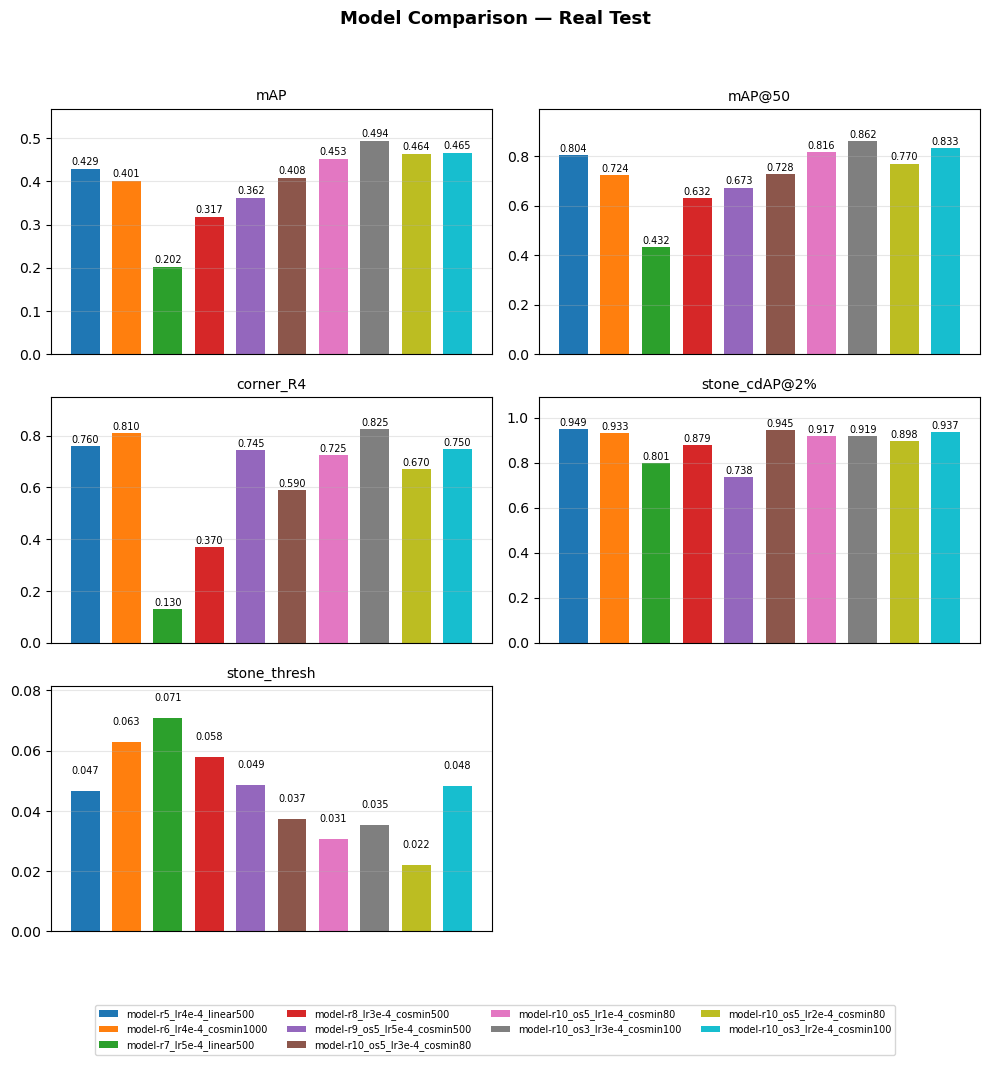

{'model-r5_lr4e-4_linear500': (np.float64(0.12156862745098039),
  np.float64(0.4666666666666667),
  np.float64(0.7058823529411765),
  np.float64(1.0)),
 'model-r6_lr4e-4_cosmin1000': (np.float64(1.0),
  np.float64(0.4980392156862745),
  np.float64(0.054901960784313725),
  np.float64(1.0)),
 'model-r7_lr5e-4_linear500': (np.float64(0.17254901960784313),
  np.float64(0.6274509803921569),
  np.float64(0.17254901960784313),
  np.float64(1.0)),
 'model-r8_lr3e-4_cosmin500': (np.float64(0.8392156862745098),
  np.float64(0.15294117647058825),
  np.float64(0.1568627450980392),
  np.float64(1.0)),
 'model-r9_os5_lr5e-4_cosmin500': (np.float64(0.5803921568627451),
  np.float64(0.403921568627451),
  np.float64(0.7411764705882353),
  np.float64(1.0)),
 'model-r10_os5_lr3e-4_cosmin80': (np.float64(0.5490196078431373),
  np.float64(0.33725490196078434),
  np.float64(0.29411764705882354),
  np.float64(1.0)),
 'model-r10_os5_lr1e-4_cosmin80': (np.float64(0.8901960784313725),
  np.float64(0.46666666666

In [8]:
import numpy as np
import pandas as pd

# ── Run evaluations on test set ──
metrics_map = {}
cd_ap = {}

for label, entry in tqdm(models.items(), desc="Evaluating models"):
    ds.set_transform(make_eval_transform(entry["ip"]))
    metrics_map[label] = evaluate_map(
        model=entry["model"],
        dataset=ds["test"],
        image_processor=entry["ip"],
        batch_size=8,
    )
    cd_ap[label] = evaluate_cd_ap(
        model=entry["model"],
        dataset=ds["test"],
        image_processor=entry["ip"],
        batch_size=8,
    )

# ── Build summary DataFrame ──
summary_rows = []
for label in models:
    row = {"model": label}
    row["mAP"] = metrics_map[label].get("map", float("nan"))
    row["mAP@50"] = metrics_map[label].get("map_50", float("nan"))
    cd = cd_ap[label]
    row["corner_R4"] = cd["corner_R4"]
    row["stone_cdAP@2%"] = np.mean([cd["per_class"][c]["cdAP@2%"] for c in ("black_stone", "white_stone")])
    opt = cd["optimal_thresholds"]
    row["stone_thresh"] = np.mean([opt[c]["threshold"] for c in ("black_stone", "white_stone")])
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

plot_model_comparison(
    summary_df,
    metrics=["mAP", "mAP@50", "corner_R4", "stone_cdAP@2%", "stone_thresh"],
    title="Model Comparison — Real Test",
    color_map=color_map,
)

In [10]:
print("Test Metrics:")
print(summary_df.to_string())

Test Metrics:
                            model       mAP    mAP@50  corner_R4  stone_cdAP@2%  stone_thresh
0       model-r5_lr4e-4_linear500  0.428675  0.803940      0.760        0.94915       0.04675
1      model-r6_lr4e-4_cosmin1000  0.401283  0.724238      0.810        0.93285       0.06285
2       model-r7_lr5e-4_linear500  0.202295  0.432089      0.130        0.80115       0.07095
3       model-r8_lr3e-4_cosmin500  0.317161  0.631793      0.370        0.87930       0.05790
4   model-r9_os5_lr5e-4_cosmin500  0.362262  0.673370      0.745        0.73790       0.04860
5   model-r10_os5_lr3e-4_cosmin80  0.408175  0.728352      0.590        0.94470       0.03740
6   model-r10_os5_lr1e-4_cosmin80  0.452549  0.816375      0.725        0.91695       0.03075
7  model-r10_os3_lr3e-4_cosmin100  0.493767  0.862200      0.825        0.91870       0.03535
8   model-r10_os5_lr2e-4_cosmin80  0.463722  0.770010      0.670        0.89815       0.02195
9  model-r10_os3_lr2e-4_cosmin100  0.465499  0

## Browse Predictions

Interactive widget to browse model predictions on dataset samples.


In [33]:
from moku.viz import browse_predictions

# Build model registry for browsing
all_models = {}
for label, entry in models.items():
    all_models[label] = {"model": entry["model"].to(device), "image_processor": entry["ip"]}

# Build dataset registry
all_datasets = {"Default": ds}

# Use optimal threshold from cdAP analysis (macro average across classes)
BROWSE_THRESHOLD = 0.05
browse_predictions(all_models, all_datasets, threshold=BROWSE_THRESHOLD)